In [1]:
## Load all necessary libraries

import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cf
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas
from matplotlib.ticker import AutoMinorLocator
import os
import scipy
from netCDF4 import Dataset as netcdf_dataset
import matplotlib
matplotlib.matplotlib_fname()
print(plt.style.available)
matplotlib.rcParams['font.sans-serif'] = 'Arial'

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
## Load all the climate model data, pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP5_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/baseline/'
#CMIP5_midc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/midcentury/'
CMIP5_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/endcentury/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/baseline/'
#CMIP6_midc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/midcentury/'
CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/endcentury/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P = np.empty(shape=(12,44,41,94+92,2))
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_base_directory):
    dirnames.sort()
    names = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
                               
            filenamelong = CMIP6_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_base_directory):
    dirnames.sort()
    names = names+sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1



In [3]:
## Generate date information

import datetime
from datetime import date
startt = date.fromisoformat('1980-01-01')
endt2 = date.fromisoformat('1981-01-01')

lats = thismod_ds.variables['lat'][53:53+44]
lons = thismod_ds.variables['lon'][11:11+41]
dates = pd.date_range(startt,endt2-datetime.timedelta(days=1),freq='m')

#dates

In [4]:
families = pd.read_csv('CMIP indexing Python.csv', sep=',',header = None)
#grid = np.array(myFile)
#gridERA5 = grid[400:505,0:105]
ids = np.array(families.loc[:,2:4])


In [5]:
## Load UKCP18

P_UKCP18 = np.empty([15, 12, 44, 40, 4]) # Empty array to fill

UKCP18_ds = xr.open_dataset('/Users/ak0920/Data/UKCP18/Global/RCP8.5/UKCP18_regridded.nc')

P_UKCP18[:,:,:,:,0] = UKCP18_ds["P_past"]
P_UKCP18[:,:,:,:,3] = UKCP18_ds["P_endc"]

lats_UKCP18 = UKCP18_ds.variables['latitude']
lons_UKCP18 = UKCP18_ds.variables['longitude']

UKCP18_change = P_UKCP18[:,:,:,:,3] - P_UKCP18[:,:,:,:,0]


# NOTE: Months in UKCP18 start at December, not January

# Calculate mean and SD
UKCP18_DJF = np.mean(P_UKCP18[:,[0,1,2],:,:], axis=1)
UKCP18_MAM = np.mean(P_UKCP18[:,[3,4,5],:,:], axis=1)
UKCP18_JJA = np.mean(P_UKCP18[:,[6,7,8],:,:], axis=1)
UKCP18_SON = np.mean(P_UKCP18[:,[9,10,11],:,:], axis=1)

UKCP18_std_DJF = np.std(UKCP18_DJF[:,:,:,:], axis=0)
UKCP18_mean_DJF = np.mean(UKCP18_DJF[:,:,:,:], axis=0)
UKCP18_std_MAM = np.std(UKCP18_MAM[:,:,:,:], axis=0)
UKCP18_mean_MAM = np.mean(UKCP18_MAM[:,:,:,:], axis=0)
UKCP18_std_JJA = np.std(UKCP18_JJA[:,:,:,:], axis=0)
UKCP18_mean_JJA = np.mean(UKCP18_JJA[:,:,:,:], axis=0)
UKCP18_std_SON = np.std(UKCP18_SON[:,:,:,:], axis=0)
UKCP18_mean_SON = np.mean(UKCP18_SON[:,:,:,:], axis=0)

UKCP18_agree_DJF = np.sum((UKCP18_DJF[:,:,:,3]-UKCP18_DJF[:,:,:,0])>0, axis=0)
UKCP18_agree_MAM = np.sum((UKCP18_MAM[:,:,:,3]-UKCP18_MAM[:,:,:,0])>0, axis=0)
UKCP18_agree_JJA = np.sum((UKCP18_JJA[:,:,:,3]-UKCP18_JJA[:,:,:,0])>0, axis=0)
UKCP18_agree_SON = np.sum((UKCP18_SON[:,:,:,3]-UKCP18_SON[:,:,:,0])>0, axis=0)

# Calculate change mean and SD
UKCP18_DJF2 = np.mean(UKCP18_change[:,[0,1,2],:,:], axis=1)
UKCP18_MAM2 = np.mean(UKCP18_change[:,[3,4,5],:,:], axis=1)
UKCP18_JJA2 = np.mean(UKCP18_change[:,[6,7,8],:,:], axis=1)
UKCP18_SON2 = np.mean(UKCP18_change[:,[9,10,11],:,:], axis=1)

UKCP18_change_std_DJF = np.std(UKCP18_DJF2[:,:,:], axis=0)
UKCP18_change_mean_DJF = np.mean(UKCP18_DJF2[:,:,:], axis=0)
UKCP18_change_std_MAM = np.std(UKCP18_MAM2[:,:,:], axis=0)
UKCP18_change_mean_MAM = np.mean(UKCP18_MAM2[:,:,:], axis=0)
UKCP18_change_std_JJA = np.std(UKCP18_JJA2[:,:,:], axis=0)
UKCP18_change_mean_JJA = np.mean(UKCP18_JJA2[:,:,:], axis=0)
UKCP18_change_std_SON = np.std(UKCP18_SON2[:,:,:], axis=0)
UKCP18_change_mean_SON = np.mean(UKCP18_SON2[:,:,:], axis=0)

# Adjust the dimension order to match CMIP
P_UKCP18_2 = np.transpose(UKCP18_DJF[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2[:,:,:,1] = np.transpose(UKCP18_DJF2[:,:,:], (1,2,0))

P_UKCP18_2a = np.transpose(UKCP18_JJA[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2a[:,:,:,1] = np.transpose(UKCP18_JJA2[:,:,:], (1,2,0))

P_UKCP18_2b = np.transpose(UKCP18_SON[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2b[:,:,:,1] = np.transpose(UKCP18_SON2[:,:,:], (1,2,0))

P_UKCP18_2d = np.transpose(UKCP18_MAM[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2d[:,:,:,1] = np.transpose(UKCP18_MAM2[:,:,:], (1,2,0))
P_UKCP18_2.shape

# Take single months
UKCP18_D = np.squeeze(P_UKCP18[:,[0],:,:])
UKCP18_J = np.squeeze(P_UKCP18[:,[1],:,:])
UKCP18_F = np.squeeze(P_UKCP18[:,[2],:,:])
UKCP18_M = np.squeeze(P_UKCP18[:,[3],:,:])
UKCP18_A = np.squeeze(P_UKCP18[:,[4],:,:])
UKCP18_May = np.squeeze(P_UKCP18[:,[5],:,:])
UKCP18_S = np.squeeze(P_UKCP18[:,[9],:,:])
UKCP18_O = np.squeeze(P_UKCP18[:,[10],:,:])
UKCP18_N = np.squeeze(P_UKCP18[:,[11],:,:])

UKCP18_D2 = np.squeeze(UKCP18_change[:,[0],:,:])
UKCP18_J2 = np.squeeze(UKCP18_change[:,[1],:,:])
UKCP18_F2 = np.squeeze(UKCP18_change[:,[2],:,:])
UKCP18_M2 = np.squeeze(UKCP18_change[:,[3],:,:])
UKCP18_A2 = np.squeeze(UKCP18_change[:,[4],:,:])
UKCP18_May2 = np.squeeze(UKCP18_change[:,[5],:,:])
UKCP18_S2 = np.squeeze(UKCP18_change[:,[9],:,:])
UKCP18_O2 = np.squeeze(UKCP18_change[:,[10],:,:])
UKCP18_N2 = np.squeeze(UKCP18_change[:,[11],:,:])

# Adjust the dimension order to match CMIP
P_UKCP18_D = np.transpose(UKCP18_D[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_D[:,:,:,1] = np.transpose(UKCP18_D2[:,:,:], (1,2,0))
P_UKCP18_J = np.transpose(UKCP18_J[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_J[:,:,:,1] = np.transpose(UKCP18_J2[:,:,:], (1,2,0))
P_UKCP18_F = np.transpose(UKCP18_F[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_F[:,:,:,1] = np.transpose(UKCP18_F2[:,:,:], (1,2,0))
P_UKCP18_M = np.transpose(UKCP18_M[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_M[:,:,:,1] = np.transpose(UKCP18_M2[:,:,:], (1,2,0))
P_UKCP18_A = np.transpose(UKCP18_A[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_A[:,:,:,1] = np.transpose(UKCP18_A2[:,:,:], (1,2,0))
P_UKCP18_May = np.transpose(UKCP18_May[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_May[:,:,:,1] = np.transpose(UKCP18_May2[:,:,:], (1,2,0))
P_UKCP18_S = np.transpose(UKCP18_S[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_S[:,:,:,1] = np.transpose(UKCP18_S2[:,:,:], (1,2,0))
P_UKCP18_O = np.transpose(UKCP18_O[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_O[:,:,:,1] = np.transpose(UKCP18_O2[:,:,:], (1,2,0))
P_UKCP18_N = np.transpose(UKCP18_N[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_N[:,:,:,1] = np.transpose(UKCP18_N2[:,:,:], (1,2,0))


In [6]:
## Load observations

obs_ids = [0,1,2,3,4,5,6,7]#[1,3,4,6,7,9,11,12,13]

thismod_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = thismod_ds["P"]
lats_obs = thismod_ds.variables['latitude']
lons_obs = thismod_ds.variables['longitude']

# Take just DJF
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+1
monids3 = monids+11
monids4 = np.concatenate((monids,monids2,monids3))

# Calculate mean and SD
obs_DJF = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_DJF = np.std(obs_DJF[obs_ids,:,:], axis=0)
obs_mean_DJF = np.mean(obs_DJF[obs_ids,:,:], axis=0)
obs_max_DJF = np.max(obs_DJF[obs_ids,:,:], axis=0)
obs_min_DJF = np.min(obs_DJF[obs_ids,:,:], axis=0)

# Take just MAM
monids = np.arange(0,360,12) + 1008
monids1 = monids+2
monids2 = monids+3
monids3 = monids+4
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_MAM = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_MAM = np.std(obs_MAM[obs_ids,:,:], axis=0)
obs_mean_MAM = np.mean(obs_MAM[obs_ids,:,:], axis=0)
obs_max_MAM = np.max(obs_MAM[obs_ids,:,:], axis=0)
obs_min_MAM = np.min(obs_MAM[obs_ids,:,:], axis=0)

# Take just JJA
monids = np.arange(0,360,12) + 1008
monids1 = monids+5
monids2 = monids+6
monids3 = monids+7
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_JJA = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_JJA = np.std(obs_JJA[obs_ids,:,:], axis=0)
obs_mean_JJA = np.mean(obs_JJA[obs_ids,:,:], axis=0)
obs_max_JJA = np.max(obs_JJA[obs_ids,:,:], axis=0)
obs_min_JJA = np.min(obs_JJA[obs_ids,:,:], axis=0)

# Take just SON
monids = np.arange(0,360,12) + 1008
monids1 = monids+8
monids2 = monids+9
monids3 = monids+10
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_SON = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_SON = np.std(obs_SON[obs_ids,:,:], axis=0)
obs_mean_SON = np.mean(obs_SON[obs_ids,:,:], axis=0)
obs_max_SON = np.max(obs_SON[obs_ids,:,:], axis=0)
obs_min_SON = np.min(obs_SON[obs_ids,:,:], axis=0)

obs_all_mons = np.stack((np.mean(P_obs[:,monids+5,:,:], axis=1),np.mean(P_obs[:,monids+6,:,:], axis=1),np.mean(P_obs[:,monids+7,:,:], axis=1),
                              np.mean(P_obs[:,monids+8,:,:], axis=1),np.mean(P_obs[:,monids+9,:,:], axis=1),np.mean(P_obs[:,monids+10,:,:], axis=1),
                              np.mean(P_obs[:,monids+11,:,:], axis=1),np.mean(P_obs[:,monids,:,:], axis=1),np.mean(P_obs[:,monids+1,:,:], axis=1),
                              np.mean(P_obs[:,monids+2,:,:], axis=1),np.mean(P_obs[:,monids+3,:,:], axis=1),np.mean(P_obs[:,monids+4,:,:], axis=1)),axis=0)



In [7]:
## Load observations for individual months
# Take just S
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+8

# Calculate mean and SD
obs_S = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_S = np.std(obs_S[obs_ids,:,:], axis=0)
obs_mean_S = np.mean(obs_S[obs_ids,:,:], axis=0)
obs_max_S = np.max(obs_S[obs_ids,:,:], axis=0)
obs_min_S = np.min(obs_S[obs_ids,:,:], axis=0)

# Take just O
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+9

# Calculate mean and SD
obs_O = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_O = np.std(obs_O[obs_ids,:,:], axis=0)
obs_mean_O = np.mean(obs_O[obs_ids,:,:], axis=0)
obs_max_O = np.max(obs_O[obs_ids,:,:], axis=0)
obs_min_O = np.min(obs_O[obs_ids,:,:], axis=0)

# Take just N
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+10

# Calculate mean and SD
obs_N = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_N = np.std(obs_N[obs_ids,:,:], axis=0)
obs_mean_N = np.mean(obs_N[obs_ids,:,:], axis=0)
obs_max_N = np.max(obs_N[obs_ids,:,:], axis=0)
obs_min_N = np.min(obs_N[obs_ids,:,:], axis=0)

# Take just D
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+11

# Calculate mean and SD
obs_D = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_D = np.std(obs_D[obs_ids,:,:], axis=0)
obs_mean_D = np.mean(obs_D[obs_ids,:,:], axis=0)
obs_max_D = np.max(obs_D[obs_ids,:,:], axis=0)
obs_min_D = np.min(obs_D[obs_ids,:,:], axis=0)

# Take just J
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids

# Calculate mean and SD
obs_J = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_J = np.std(obs_J[obs_ids,:,:], axis=0)
obs_mean_J = np.mean(obs_J[obs_ids,:,:], axis=0)
obs_max_J = np.max(obs_J[obs_ids,:,:], axis=0)
obs_min_J = np.min(obs_J[obs_ids,:,:], axis=0)

# Take just F
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+1

# Calculate mean and SD
obs_F = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_F = np.std(obs_F[obs_ids,:,:], axis=0)
obs_mean_F = np.mean(obs_F[obs_ids,:,:], axis=0)
obs_max_F = np.max(obs_F[obs_ids,:,:], axis=0)
obs_min_F = np.min(obs_F[obs_ids,:,:], axis=0)

# Take just M
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+2

# Calculate mean and SD
obs_M = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_M = np.std(obs_M[obs_ids,:,:], axis=0)
obs_mean_M = np.mean(obs_M[obs_ids,:,:], axis=0)
obs_max_M = np.max(obs_M[obs_ids,:,:], axis=0)
obs_min_M = np.min(obs_M[obs_ids,:,:], axis=0)

# Take just A
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+3

# Calculate mean and SD
obs_A = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_A = np.std(obs_A[obs_ids,:,:], axis=0)
obs_mean_A = np.mean(obs_A[obs_ids,:,:], axis=0)
obs_max_A = np.max(obs_A[obs_ids,:,:], axis=0)
obs_min_A = np.min(obs_A[obs_ids,:,:], axis=0)

# Take just May
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+3

# Calculate mean and SD
obs_May = np.mean(P_obs[:,monids2,:,:], axis=1)
obs_std_May = np.std(obs_May[obs_ids,:,:], axis=0)
obs_mean_May = np.mean(obs_May[obs_ids,:,:], axis=0)
obs_max_May = np.max(obs_May[obs_ids,:,:], axis=0)
obs_min_May = np.min(obs_May[obs_ids,:,:], axis=0)




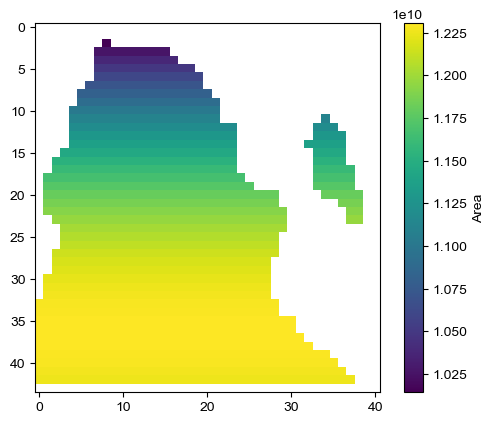

In [8]:
## Create Land-Sea Mask
# This is quite long, but it is quick and ensures a consistent LSM with the obs analysis
# Load observations
obs_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = obs_ds["P"]
lats_obs = obs_ds.variables['latitude']
lons_obs = obs_ds.variables['longitude']

# Convert data to numpy array
P_obs_arr = np.array(P_obs)

# To avoid mismatches in LSM relative to obs datasets, calculate LSM based on where obs are available
LSM1 = np.sum(np.isnan(P_obs_arr[:,1344,:,:,]),axis=0)
LSM2 = LSM1>0
LSM = np.abs(LSM2*1-1)

# Make ocean points NaN
mask_land = np.ones(LSM.shape)
for i in range(0,44):
    for j in range(0,41):        
        if LSM[i,j]==0:
            mask_land[i,j] = np.nan
            
# Calculate the global lat-long area per 1° grid cell
# Assuming the earth is a perfect sphere
def gridsize(lat1):
   #https://en.wikipedia.org/wiki/Haversine_formula
   #https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters/11172685#11172685
   lon1=200
   import math
   lat2=lat1
   lon2=lon1+1

   R = 6378.137 # // Radius of earth in km
   dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
   dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
   a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
   c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
   d = R * c
   return d * 1000 #; // meters

boxlo,boxla=np.array(np.meshgrid(np.arange(-179.5,180.5,1),np.arange(-89.5,90.5,1)))
sizes=np.ones(boxlo.shape)
grid=gridsize(boxla)
grid_nc=xr.DataArray(grid,coords={'lat':boxla[:,1],'lon':boxlo[1,:]},dims=['lat','lon'])
lat_size=110567 #in m
grid_nc['m2']=grid_nc*lat_size
grid_nc=grid_nc['m2']

# Find ID of longitudes of global area grid for subset region where obs are available
lon_ids = np.arange(0,360,1)
which_id = boxlo[0,:] == np.array(lons_obs[0])
lon_id1 = lon_ids[which_id].item()
which_id = boxlo[0,:] == np.array(lons_obs[-1])
lon_id2 = lon_ids[which_id].item()+1
subsetlo = boxlo[0,lon_id1:lon_id2]

## Find ID of latitudes of global area grid for subset region
lat_ids = np.arange(0,180,1)
which_id = boxla[:,0] == np.array(lats_obs[0])
lat_id1 = lat_ids[which_id].item()
which_id = boxla[:,0] == np.array(lats_obs[-1])
lat_id2 = lat_ids[which_id].item()+1
subsetla = boxla[lat_id1:lat_id2,0]

## Create area-weighted LSM
LSM_area = grid_nc[lat_id1:lat_id2,lon_id1:lon_id2]*mask_land

# Create plot to check
plt.imshow(LSM_area)
cbar = plt.colorbar(label="Area")
plt.show()

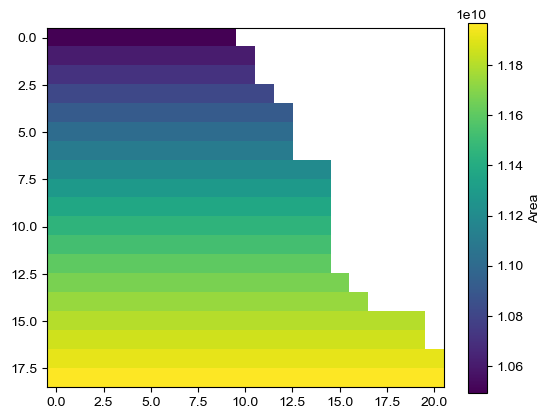

In [9]:
# Define Large regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop
regno = 0;

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_d = np.repeat(areas2d[:, :, np.newaxis], 8, axis=2)
areas4d_d = np.repeat(areas3d_d[:, :, :, np.newaxis], 12, axis=3)
# Convert to a fractional area
areas3d_frac_d = areas3d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
areas4d_frac_d = areas4d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)


# Area means for models
y_all = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18a = np.nansum(np.nansum(P_UKCP18_2a[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18b = np.nansum(np.nansum(P_UKCP18_2b[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18d = np.nansum(np.nansum(P_UKCP18_2d[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_DJF = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_MAM = np.nansum(np.nansum(np.mean(P[[2,3,4],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_JJA = np.nansum(np.nansum(np.mean(P[[5,6,7],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_SON = np.nansum(np.nansum(np.mean(P[[8,9,10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)


# Area means for observations
obs_only_SON = np.transpose(np.array(obs_SON), (1,2,0))
y_obs_SON = np.nansum(np.nansum(obs_only_SON[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_DJF = np.transpose(np.array(obs_DJF), (1,2,0))
y_obs_DJF = np.nansum(np.nansum(obs_only_DJF[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_MAM = np.transpose(np.array(obs_MAM), (1,2,0))
y_obs_MAM = np.nansum(np.nansum(obs_only_MAM[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_JJA = np.transpose(np.array(obs_JJA), (1,2,0))
y_obs_JJA = np.nansum(np.nansum(obs_only_JJA[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

y_obs_mons = obs_all_mons[:,obs_ids,:,0:41]
y_obs_mons_2 = np.transpose(np.array(y_obs_mons), (2,3,1,0))
y_obs_mons_plot = np.nansum(np.nansum(y_obs_mons_2[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas4d_frac_d, axis=1), axis=0)


# Create plot to check
plt.imshow(areas2d)
cbar = plt.colorbar(label="Area")
plt.show()

In [10]:
# As above, but for months

# Area means for models
y_UKCP18_S = np.nansum(np.nansum(P_UKCP18_S[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_O = np.nansum(np.nansum(P_UKCP18_O[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_N = np.nansum(np.nansum(P_UKCP18_N[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_D = np.nansum(np.nansum(P_UKCP18_D[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_J = np.nansum(np.nansum(P_UKCP18_J[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_F = np.nansum(np.nansum(P_UKCP18_F[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_M = np.nansum(np.nansum(P_UKCP18_M[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_A = np.nansum(np.nansum(P_UKCP18_A[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_UKCP18_May = np.nansum(np.nansum(P_UKCP18_May[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)

y_S = np.nansum(np.nansum(np.mean(P[[8],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_O = np.nansum(np.nansum(np.mean(P[[9],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_N = np.nansum(np.nansum(np.mean(P[[10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_D = np.nansum(np.nansum(np.mean(P[[11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_J = np.nansum(np.nansum(np.mean(P[[0],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_F = np.nansum(np.nansum(np.mean(P[[1],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_M = np.nansum(np.nansum(np.mean(P[[2],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_A = np.nansum(np.nansum(np.mean(P[[3],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_May = np.nansum(np.nansum(np.mean(P[[4],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)


# Area means for observations
obs_only_S = np.transpose(np.array(obs_S), (1,2,0))
y_obs_S = np.nansum(np.nansum(obs_only_S[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_O = np.transpose(np.array(obs_O), (1,2,0))
y_obs_O = np.nansum(np.nansum(obs_only_O[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_N = np.transpose(np.array(obs_N), (1,2,0))
y_obs_N = np.nansum(np.nansum(obs_only_N[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_D = np.transpose(np.array(obs_D), (1,2,0))
y_obs_D = np.nansum(np.nansum(obs_only_D[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_J = np.transpose(np.array(obs_J), (1,2,0))
y_obs_J = np.nansum(np.nansum(obs_only_J[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_F = np.transpose(np.array(obs_F), (1,2,0))
y_obs_F = np.nansum(np.nansum(obs_only_F[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_M = np.transpose(np.array(obs_M), (1,2,0))
y_obs_M = np.nansum(np.nansum(obs_only_M[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_A = np.transpose(np.array(obs_A), (1,2,0))
y_obs_A = np.nansum(np.nansum(obs_only_A[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

obs_only_May = np.transpose(np.array(obs_May), (1,2,0))
y_obs_May = np.nansum(np.nansum(obs_only_May[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)




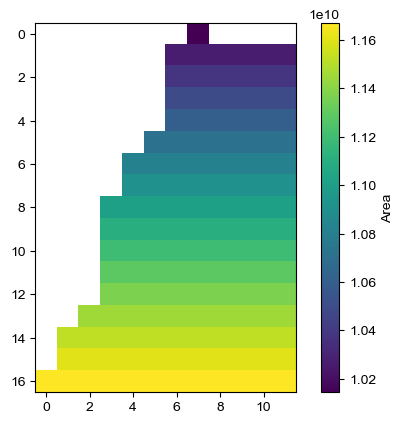

In [11]:
# Define West regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop
regno = 2;

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_d = np.repeat(areas2d[:, :, np.newaxis], 8, axis=2)
areas4d_d = np.repeat(areas3d_d[:, :, :, np.newaxis], 12, axis=3)
# Convert to a fractional area
areas3d_frac_d = areas3d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
areas4d_frac_d = areas4d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)


# Area means for models
y_all_west = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_UKCP18_west = np.nansum(np.nansum(P_UKCP18_2[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_DJF_west = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)

# Area means for observations
obs_only_DJF_west = np.transpose(np.array(obs_DJF), (1,2,0))
y_obs_DJF_west = np.nansum(np.nansum(obs_only_DJF_west[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)

# Create plot to check
plt.imshow(areas2d)
cbar = plt.colorbar(label="Area")
plt.show()

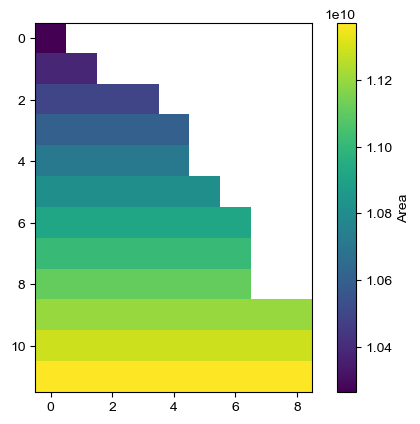

In [12]:
# Define East regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop
regno = 3;

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_d = np.repeat(areas2d[:, :, np.newaxis], 8, axis=2)
areas4d_d = np.repeat(areas3d_d[:, :, :, np.newaxis], 12, axis=3)
# Convert to a fractional area
areas3d_frac_d = areas3d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
areas4d_frac_d = areas4d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)


# Area means for models
y_all_east = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
y_UKCP18_east = np.nansum(np.nansum(P_UKCP18_2[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
y_DJF_east = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)


# Area means for observations
obs_only_DJF_east = np.transpose(np.array(obs_DJF), (1,2,0))
y_obs_DJF_east = np.nansum(np.nansum(obs_only_DJF_east[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas3d_frac_d, axis=1), axis=0)


# Create plot to check
plt.imshow(areas2d)
cbar = plt.colorbar(label="Area")
plt.show()

/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/3389114040.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/3389114040.py:66: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,1].scatter(y_SON[i,0], y_SON[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/3389114040.py:110: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/3389114040.py:146: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/3389114040.py:183: UserWarning: No data for colormapping provided via

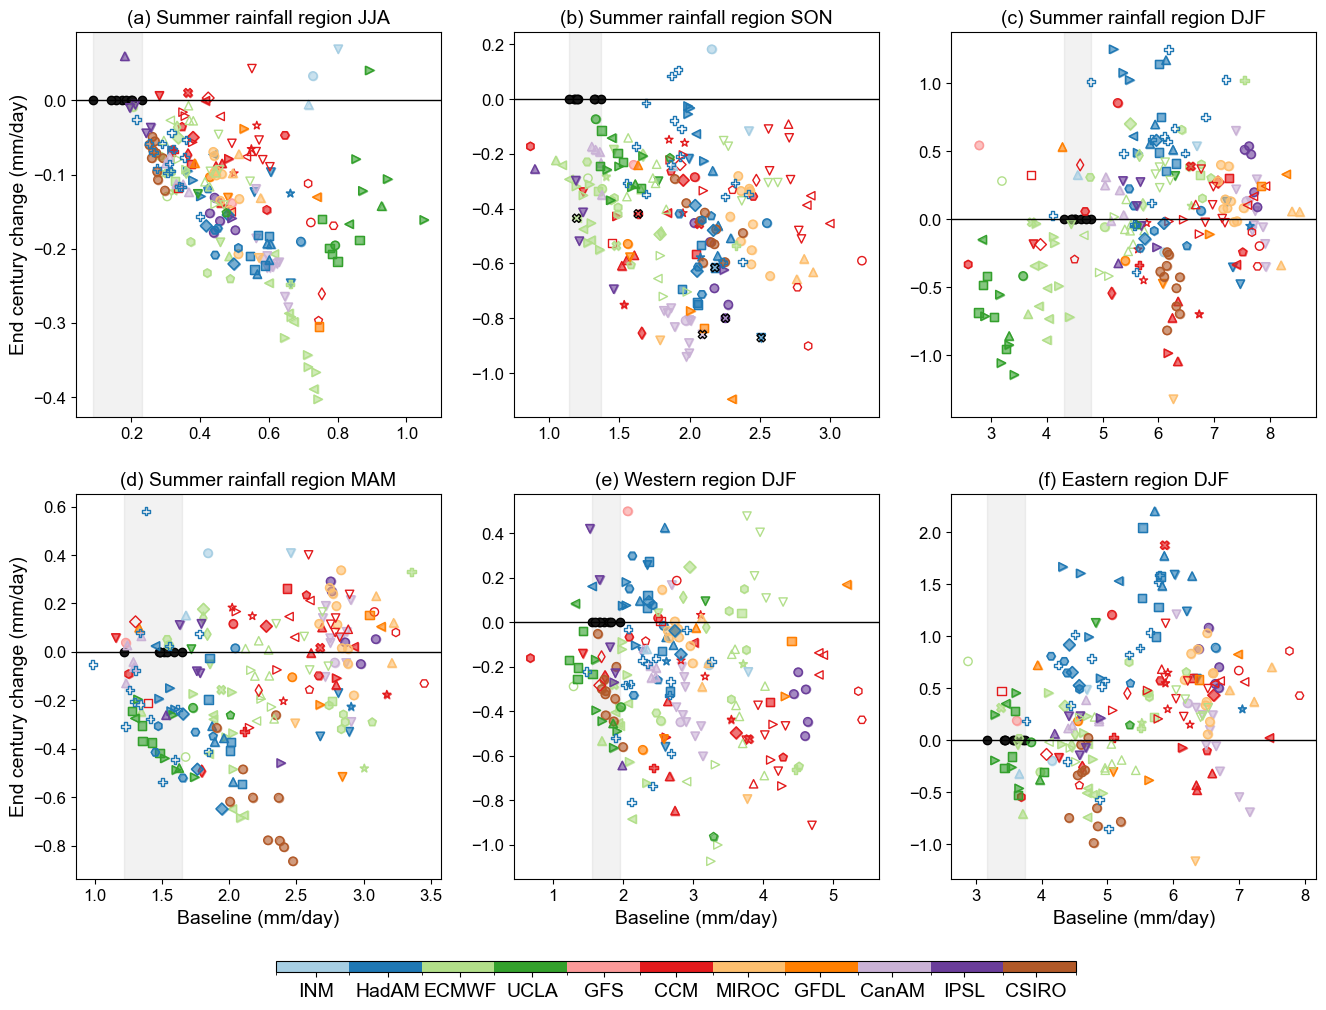

In [29]:
## Create Figure 5

# Define a set of colours for plotting
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
matplotlib.rcParams['xtick.labelsize'] = 12 
matplotlib.rcParams['ytick.labelsize'] = 12 

# colors = cm.Paired(np.linspace(0, 1, 12))
colors2 = cm.Paired(np.linspace(0, 1, 12))
colors = colors2[[0,1,2,3,4,5,6,7,8,9,11],:]

fig, axs = plt.subplots(2,3, figsize=(16,11))
#fig, ax = plt.subplots()
#ax.set_facecolor((0.975, 0.975, 0.975))


axs[0,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,0].axvspan(np.min(y_obs_JJA),np.max(y_obs_JJA), alpha=0.1, color='gray')
axs[0,0].scatter(y_obs_JJA, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,0].scatter(y_UKCP18a[:,0],y_UKCP18a[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
 

    
axs[0,0].set_title('(a) Summer rainfall region JJA',fontname = 'arial', fontsize=14)
axs[0,0].set_ylabel('End century change (mm/day)', fontsize=14)
# axs[0,0].set_xlabel('Baseline (mm/day)', fontsize=14);


axs[0,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,1].axvspan(np.min(y_obs_SON),np.max(y_obs_SON), alpha=0.1, color='gray')
axs[0,1].scatter(y_obs_SON, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
        
axs[0,1].scatter(y_SON[3,0], y_SON[3,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[22,0], y_SON[22,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[29,0], y_SON[29,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[63,0], y_SON[63,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[87,0], y_SON[87,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[89,0], y_SON[89,1], facecolors='none', edgecolors='k',marker='X')

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,1].scatter(y_UKCP18b[:,0],y_UKCP18b[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[0,1].set_title('(b) Summer rainfall region SON',fontname = 'arial', fontsize=14)
# axs[0,1].set_ylabel('End century change (mm/day)', fontsize=14)
# axs[0,1].set_xlabel('Baseline (mm/day)', fontsize=14);


axs[0,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,2].axvspan(np.min(y_obs_DJF),np.max(y_obs_DJF), alpha=0.1, color='gray')
axs[0,2].scatter(y_obs_DJF, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,2].scatter(y_UKCP18[:,0],y_UKCP18[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[0,2].set_title('(c) Summer rainfall region DJF',fontname = 'arial', fontsize=14)
# axs[0,2].set_ylabel('End century change (mm/day)', fontsize=14)
# axs[0,2].set_xlabel('Baseline (mm/day)', fontsize=14);


axs[1,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,0].axvspan(np.min(y_obs_MAM),np.max(y_obs_MAM), alpha=0.1, color='gray')
axs[1,0].scatter(y_obs_MAM, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,0].scatter(y_UKCP18d[:,0],y_UKCP18d[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[1,0].set_title('(d) Summer rainfall region MAM',fontname = 'arial', fontsize=14)
axs[1,0].set_ylabel('End century change (mm/day)', fontsize=14)
axs[1,0].set_xlabel('Baseline (mm/day)', fontsize=14);



axs[1,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,1].axvspan(np.min(y_obs_DJF_west),np.max(y_obs_DJF_west), alpha=0.1, color='gray')
axs[1,1].scatter(y_obs_DJF_west, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,1].scatter(y_UKCP18_west[:,0],y_UKCP18_west[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[1,1].set_title('(e) Western region DJF',fontname = 'arial', fontsize=14)
# axs[1,1].set_ylabel('End century change (mm/day)', fontsize=14)
axs[1,1].set_xlabel('Baseline (mm/day)', fontsize=14);



axs[1,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,2].axvspan(np.min(y_obs_DJF_east),np.max(y_obs_DJF_east), alpha=0.1, color='gray')
axs[1,2].scatter(y_obs_DJF_east, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all_east[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,2].scatter(y_UKCP18_east[:,0],y_UKCP18_east[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)
        
axs[1,2].set_title('(f) Eastern region DJF',fontname = 'arial', fontsize=14)
# axs[1,2].set_ylabel('End century change (mm/day)', fontsize=14)
axs[1,2].set_xlabel('Baseline (mm/day)', fontsize=14);


# create a second axes for the colorbar
ax2 = fig.add_axes([0.25, 0.025, 0.5, 0.01])
cb = matplotlib.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
    spacing='proportional', ticks=tbounds,orientation='horizontal')
cb.ax.set_xticklabels(['INM','HadAM','ECMWF','UCLA','GFS','CCM','MIROC','GFDL','CanAM','IPSL','CSIRO'])  # horizontal colorbar
cb.ax.tick_params(labelsize=14)


plt.savefig('Fig5_families_revised.pdf')

/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/2267390929.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/2267390929.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,1].scatter(y_SON[i,0], y_SON[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/2267390929.py:108: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/2267390929.py:144: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_94155/2267390929.py:181: UserWarning: No data for colormapping provided via

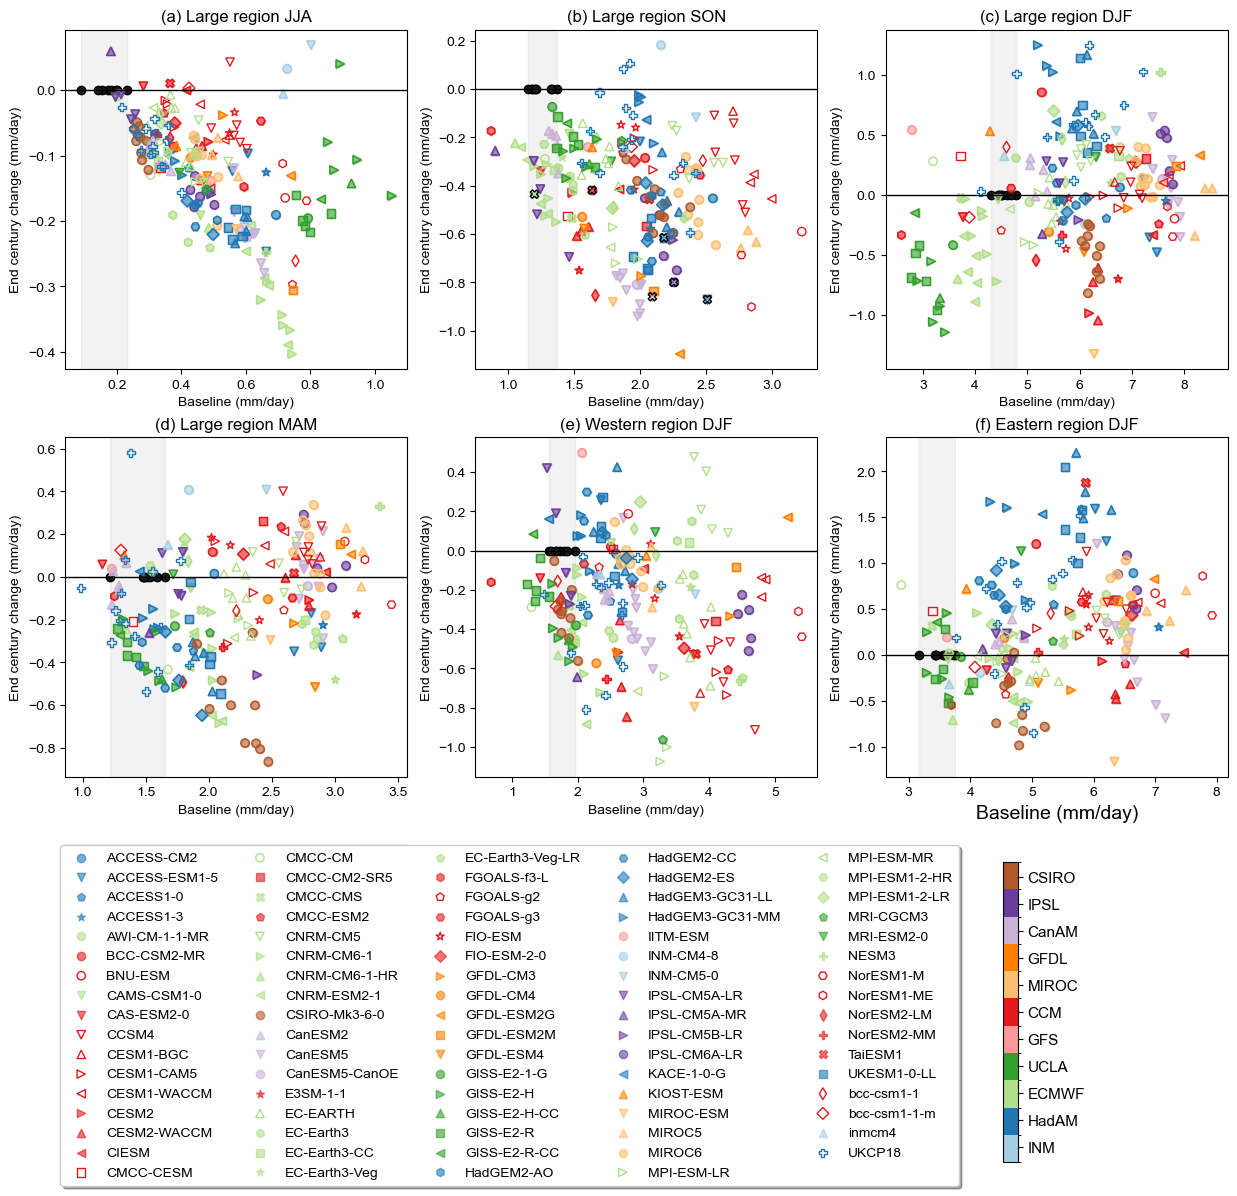

In [18]:
## Create Figure 5

# Define a set of colours for plotting
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable

# colors = cm.Paired(np.linspace(0, 1, 12))
colors2 = cm.Paired(np.linspace(0, 1, 12))
colors = colors2[[0,1,2,3,4,5,6,7,8,9,11],:]

fig, axs = plt.subplots(3,3, figsize=(15,15))
#fig, ax = plt.subplots()
#ax.set_facecolor((0.975, 0.975, 0.975))


axs[0,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,0].axvspan(np.min(y_obs_JJA),np.max(y_obs_JJA), alpha=0.1, color='gray')
axs[0,0].scatter(y_obs_JJA, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,0].scatter(y_JJA[i,0], y_JJA[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,0].scatter(y_UKCP18a[:,0],y_UKCP18a[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
 

    
axs[0,0].set_title('(a) Large region JJA',fontname = 'arial')
axs[0,0].set_ylabel('End century change (mm/day)')
axs[0,0].set_xlabel('Baseline (mm/day)');


axs[0,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,1].axvspan(np.min(y_obs_SON),np.max(y_obs_SON), alpha=0.1, color='gray')
axs[0,1].scatter(y_obs_SON, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,1].scatter(y_SON[i,0], y_SON[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
        
axs[0,1].scatter(y_SON[3,0], y_SON[3,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[22,0], y_SON[22,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[29,0], y_SON[29,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[63,0], y_SON[63,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[87,0], y_SON[87,1], facecolors='none', edgecolors='k',marker='X')
axs[0,1].scatter(y_SON[89,0], y_SON[89,1], facecolors='none', edgecolors='k',marker='X')

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,1].scatter(y_UKCP18b[:,0],y_UKCP18b[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[0,1].set_title('(b) Large region SON',fontname = 'arial')
axs[0,1].set_ylabel('End century change (mm/day)')
axs[0,1].set_xlabel('Baseline (mm/day)');


axs[0,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,2].axvspan(np.min(y_obs_DJF),np.max(y_obs_DJF), alpha=0.1, color='gray')
axs[0,2].scatter(y_obs_DJF, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,2].scatter(y_DJF[i,0], y_DJF[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,2].scatter(y_UKCP18[:,0],y_UKCP18[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[0,2].set_title('(c) Large region DJF',fontname = 'arial')
axs[0,2].set_ylabel('End century change (mm/day)')
axs[0,2].set_xlabel('Baseline (mm/day)');


axs[1,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,0].axvspan(np.min(y_obs_MAM),np.max(y_obs_MAM), alpha=0.1, color='gray')
axs[1,0].scatter(y_obs_MAM, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,0].scatter(y_MAM[i,0], y_MAM[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,0].scatter(y_UKCP18d[:,0],y_UKCP18d[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[1,0].set_title('(d) Large region MAM',fontname = 'arial')
axs[1,0].set_ylabel('End century change (mm/day)')
axs[1,0].set_xlabel('Baseline (mm/day)');



axs[1,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,1].axvspan(np.min(y_obs_DJF_west),np.max(y_obs_DJF_west), alpha=0.1, color='gray')
axs[1,1].scatter(y_obs_DJF_west, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,1].scatter(y_DJF_west[i,0], y_DJF_west[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,1].scatter(y_UKCP18_west[:,0],y_UKCP18_west[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[1,1].set_title('(e) Western region DJF',fontname = 'arial')
axs[1,1].set_ylabel('End century change (mm/day)')
axs[1,1].set_xlabel('Baseline (mm/day)');



axs[1,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,2].axvspan(np.min(y_obs_DJF_east),np.max(y_obs_DJF_east), alpha=0.1, color='gray')
axs[1,2].scatter(y_obs_DJF_east, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all_east[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,2].scatter(y_DJF_east[i,0], y_DJF_east[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,2].scatter(y_UKCP18_east[:,0],y_UKCP18_east[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)
        
axs[1,2].set_title('(f) Eastern region DJF',fontname = 'arial')
axs[1,2].set_ylabel('End century change (mm/day)')
axs[1,2].set_xlabel('Baseline (mm/day)');



## Create key
name, m_id = np.unique(families.loc[:,1],return_index=True)

axs[2,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
count = 1
for ii in range(0,len(m_id)):
    i = m_id[ii]
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[2,0].scatter(1, count, 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors,label=name[ii])

        count=count+1
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[2,0].scatter(1, count,  
              facecolors='none', edgecolors=markeredgecol,
              marker=marks,label=name[ii])
        count=count+1
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[2,0].scatter(1,1,facecolors='none', edgecolors=markeredgecol,marker=marks,label='UKCP18')
axs[2,0].tick_params(axis='x',which='both',bottom=False,top=False,labelbottom=False)
axs[2,0].tick_params(axis='y',which='both',left=False,right=False,labelleft=False)
axs[2,0].legend(loc='upper center', bbox_to_anchor=(1.3, 1.021),
          fancybox=True, shadow=True, ncol=5,facecolor=(1,1,1),framealpha=1,borderpad=0.5)
axs[2,1].remove()
axs[2,2].remove()
#plt.show()
# plt.savefig('Families_legend.pdf')

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', colors, 11)
bounds = np.linspace(0, 1, 12)
tbounds = np.linspace(0.05, 0.95, 11)
norm = matplotlib.colors.BoundaryNorm(bounds, 11)

# create a second axes for the colorbar
ax2 = fig.add_axes([0.75, 0.125, 0.01, 0.2])
cb = matplotlib.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
    spacing='proportional', ticks=tbounds)
cb.ax.set_yticklabels(['INM','HadAM','ECMWF','UCLA','GFS','CCM','MIROC','GFDL','CanAM','IPSL','CSIRO'])  # horizontal colorbar
cb.ax.tick_params(labelsize=11)


plt.savefig('Fig5_families.pdf')

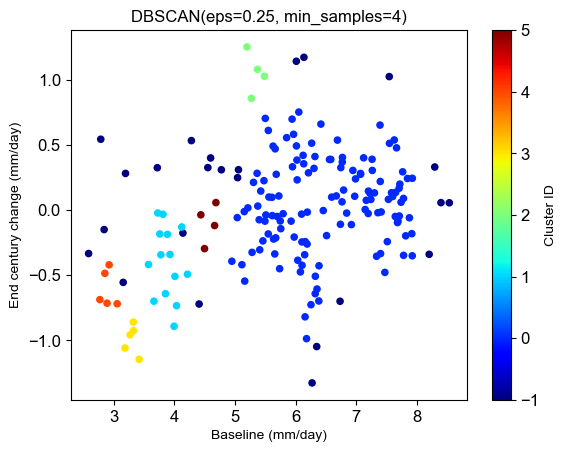

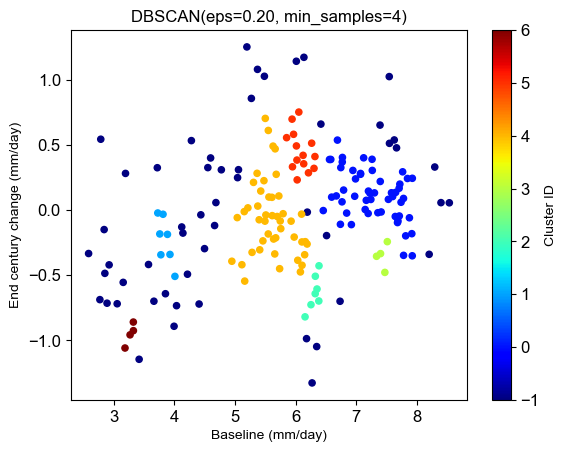

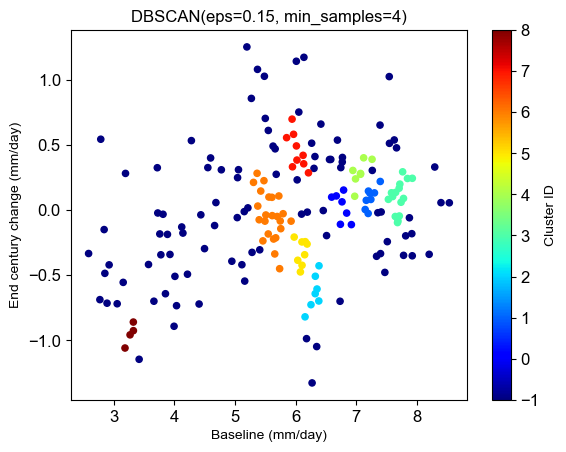

In [86]:
## Cluster analysis

from sklearn.cluster import DBSCAN
# data = pd.DataFrame({'Baseline': y_DJF[:,0], 'Change': y_DJF[:,1],'Family': families.loc[:,2]})
data = pd.DataFrame({'Baseline (mm/day)': y_DJF[:,0], 'End century change (mm/day)': y_DJF[:,1]})
# data = pd.DataFrame({'Baseline': y_DJF[:,0], 'Change': y_DJF[:,1],'BaselineS': y_SON[:,0], 'ChangeS': y_SON[:,1]})



db = DBSCAN(eps=0.25, min_samples=4).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
result.plot.scatter(x='Baseline (mm/day)',y='End century change (mm/day)',c='Cluster ID', colormap='jet')
plt.title('DBSCAN(eps=0.25, min_samples=4)',fontname = 'arial')
plt.savefig('DBSCAN_example1.pdf')

db = DBSCAN(eps=0.2, min_samples=4).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
result.plot.scatter(x='Baseline (mm/day)',y='End century change (mm/day)',c='Cluster ID', colormap='jet')
plt.title('DBSCAN(eps=0.20, min_samples=4)',fontname = 'arial')
plt.savefig('DBSCAN_example2.pdf')

db = DBSCAN(eps=0.15, min_samples=4).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
result.plot.scatter(x='Baseline (mm/day)',y='End century change (mm/day)',c='Cluster ID', colormap='jet')
plt.title('DBSCAN(eps=0.15, min_samples=4)',fontname = 'arial')
plt.savefig('DBSCAN_example3.pdf')

KeyError: 'Name'

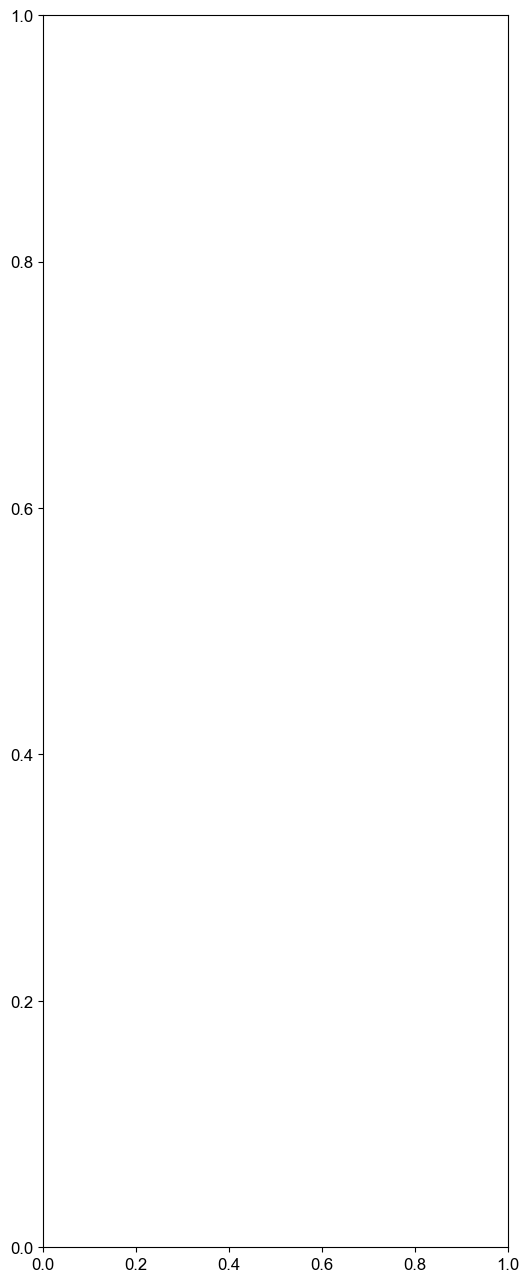

In [30]:
## Cluster analysis across regions

from sklearn.cluster import DBSCAN
#data = pd.DataFrame({'CMIP': families.loc[:,0],'Name': families.loc[:,1],'BaselineW': y_all[:,0], 'ChangeW': y_all[:,1],'Family': families.loc[:,2]})
# data = pd.DataFrame({'CMIP': families.loc[:,0],'Name': families.loc[:,1],'BaselineM': y_MAM[:,0], 'ChangeM': y_MAM[:,1],'BaselineJ': y_JJA[:,0], 'ChangeJ': y_JJA[:,1],'BaselineS': y_SON[:,0], 'ChangeS': y_SON[:,1],'BaselineD': y_DJF[:,0], 'ChangeD': y_DJF[:,1]})
data = pd.DataFrame({'CMIP': families.loc[:,0],'Name': families.loc[:,1],'BaselineM': y_MAM[:,0], 'ChangeM': y_MAM[:,1],'BaselineJ': y_JJA[:,0], 'ChangeJ': y_JJA[:,1],'BaselineS': y_SON[:,0], 'ChangeS': y_SON[:,1],'BaselineD': y_DJF[:,0], 'ChangeD': y_DJF[:,1]})

from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(6,16))

names = data['Name']
Y = data['CMIP']
X = data.drop(['Name','CMIP'],axis=1)
Z = hierarchy.linkage(X.to_numpy(), 'complete')
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')
plt.savefig('k-means_multi-season.pdf')



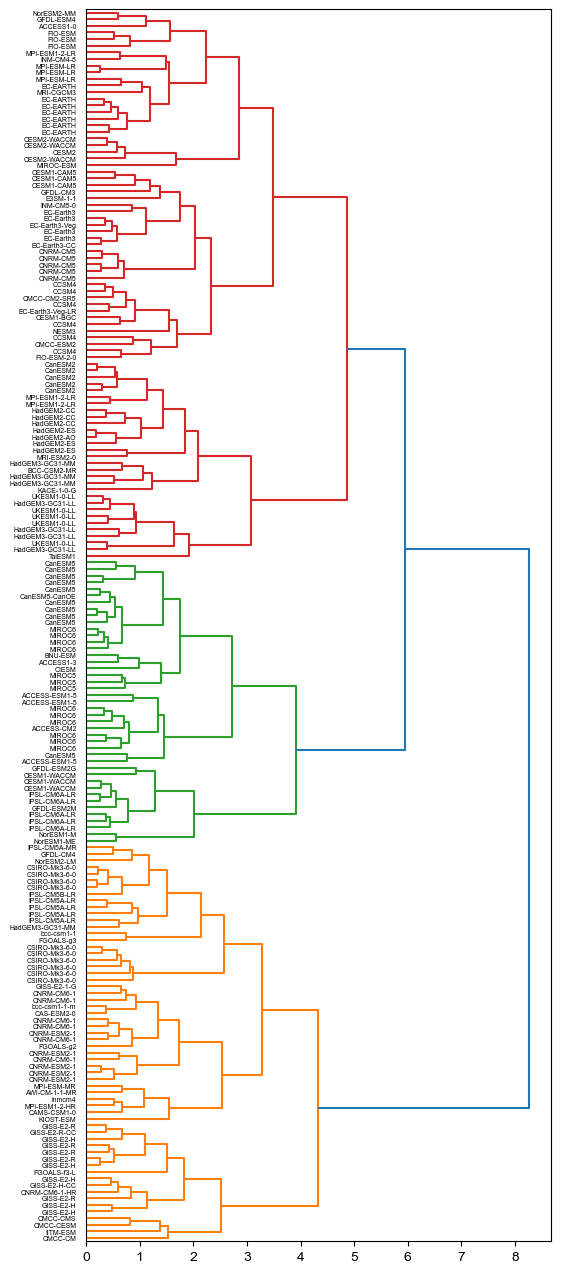

In [16]:
## Cluster analysis across regions

from sklearn.cluster import DBSCAN
#data = pd.DataFrame({'CMIP': families.loc[:,0],'Name': families.loc[:,1],'BaselineW': y_all[:,0], 'ChangeW': y_all[:,1],'Family': families.loc[:,2]})
data = pd.DataFrame({'CMIP': families.loc[:,0],'Name': families.loc[:,1],'BaselineW': y_DJF_west[:,0], 'ChangeW': y_DJF_west[:,1],'BaselineE': y_DJF_east[:,0], 'ChangeE': y_DJF_east[:,1],'BaselineL': y_DJF[:,0], 'ChangeL': y_DJF[:,1]})

from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(6,16))

names = data['Name']
Y = data['CMIP']
X = data.drop(['Name','CMIP'],axis=1)
Z = hierarchy.linkage(X.to_numpy(), 'complete')
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')
plt.savefig('k-means_multi-reg_DJF.pdf')



/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_78510/319057421.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,0].scatter(y_S[i,0], y_S[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_78510/319057421.py:64: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,1].scatter(y_O[i,0], y_O[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_78510/319057421.py:102: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0,2].scatter(y_N[i,0], y_N[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_78510/319057421.py:146: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1,0].scatter(y_D[i,0], y_D[i,1],
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_78510/319057421.py:182: UserWarning: No data for colormapping provided via 'c'. Parameters 'cma

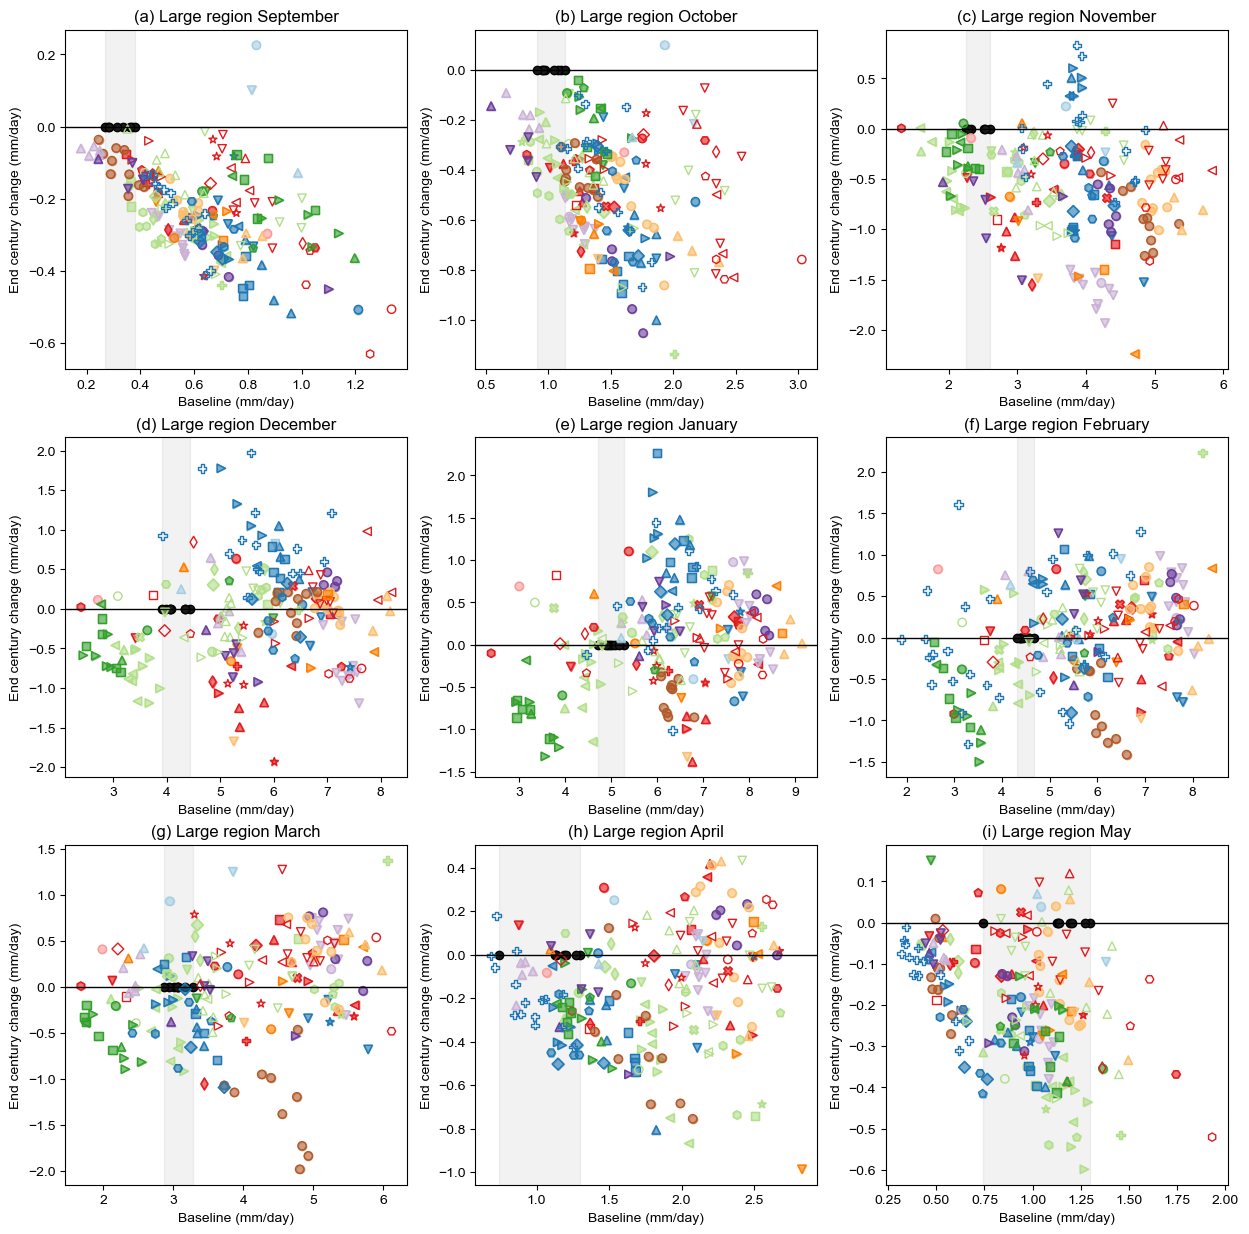

In [20]:
## Create Supp Figure Y

# Define a set of colours for plotting
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable

# colors = cm.Paired(np.linspace(0, 1, 12))
colors2 = cm.Paired(np.linspace(0, 1, 12))
colors = colors2[[0,1,2,3,4,5,6,7,8,9,11],:]

fig, axs = plt.subplots(3,3, figsize=(15,15))
#fig, ax = plt.subplots()
#ax.set_facecolor((0.975, 0.975, 0.975))

axs[0,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,0].axvspan(np.min(y_obs_S),np.max(y_obs_S), alpha=0.1, color='gray')
axs[0,0].scatter(y_obs_S, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,0].scatter(y_S[i,0], y_S[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,0].scatter(y_S[i,0], y_S[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,0].scatter(y_S[i,0], y_S[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,0].scatter(y_UKCP18_S[:,0],y_UKCP18_S[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
 

    
axs[0,0].set_title('(a) Large region September',fontname = 'arial')
axs[0,0].set_ylabel('End century change (mm/day)')
axs[0,0].set_xlabel('Baseline (mm/day)');



axs[0,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,1].axvspan(np.min(y_obs_O),np.max(y_obs_O), alpha=0.1, color='gray')
axs[0,1].scatter(y_obs_O, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,1].scatter(y_O[i,0], y_O[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,1].scatter(y_O[i,0], y_O[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,1].scatter(y_O[i,0], y_O[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,1].scatter(y_UKCP18_O[:,0],y_UKCP18_O[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
 

    
axs[0,1].set_title('(b) Large region October',fontname = 'arial')
axs[0,1].set_ylabel('End century change (mm/day)')
axs[0,1].set_xlabel('Baseline (mm/day)');


axs[0,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[0,2].axvspan(np.min(y_obs_N),np.max(y_obs_N), alpha=0.1, color='gray')
axs[0,2].scatter(y_obs_N, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[0,2].scatter(y_N[i,0], y_N[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[0,2].scatter(y_N[i,0], y_N[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[0,2].scatter(y_N[i,0], y_N[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
        
# axs[0,1].scatter(y_SON[3,0], y_SON[3,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[22,0], y_SON[22,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[29,0], y_SON[29,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[63,0], y_SON[63,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[87,0], y_SON[87,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[89,0], y_SON[89,1], facecolors='none', edgecolors='k',marker='X')

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[0,2].scatter(y_UKCP18_N[:,0],y_UKCP18_N[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[0,2].set_title('(c) Large region November',fontname = 'arial')
axs[0,2].set_ylabel('End century change (mm/day)')
axs[0,2].set_xlabel('Baseline (mm/day)');


axs[1,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,0].axvspan(np.min(y_obs_D),np.max(y_obs_D), alpha=0.1, color='gray')
axs[1,0].scatter(y_obs_D, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,0].scatter(y_D[i,0], y_D[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,0].scatter(y_D[i,0], y_D[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,0].scatter(y_D[i,0], y_D[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,0].scatter(y_UKCP18_D[:,0],y_UKCP18_D[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[1,0].set_title('(d) Large region December',fontname = 'arial')
axs[1,0].set_ylabel('End century change (mm/day)')
axs[1,0].set_xlabel('Baseline (mm/day)');


axs[1,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,1].axvspan(np.min(y_obs_J),np.max(y_obs_J), alpha=0.1, color='gray')
axs[1,1].scatter(y_obs_J, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,1].scatter(y_J[i,0], y_J[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,1].scatter(y_J[i,0], y_J[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,1].scatter(y_J[i,0], y_J[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,1].scatter(y_UKCP18_J[:,0],y_UKCP18_J[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[1,1].set_title('(e) Large region January',fontname = 'arial')
axs[1,1].set_ylabel('End century change (mm/day)')
axs[1,1].set_xlabel('Baseline (mm/day)');


axs[1,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[1,2].axvspan(np.min(y_obs_F),np.max(y_obs_F), alpha=0.1, color='gray')
axs[1,2].scatter(y_obs_F, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[1,2].scatter(y_F[i,0], y_F[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[1,2].scatter(y_F[i,0], y_F[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[1,2].scatter(y_F[i,0], y_F[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
        
# axs[0,1].scatter(y_SON[3,0], y_SON[3,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[22,0], y_SON[22,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[29,0], y_SON[29,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[63,0], y_SON[63,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[87,0], y_SON[87,1], facecolors='none', edgecolors='k',marker='X')
# axs[0,1].scatter(y_SON[89,0], y_SON[89,1], facecolors='none', edgecolors='k',marker='X')

all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,2].scatter(y_UKCP18_F[:,0],y_UKCP18_F[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[1,2].set_title('(f) Large region February',fontname = 'arial')
axs[1,2].set_ylabel('End century change (mm/day)')
axs[1,2].set_xlabel('Baseline (mm/day)');


axs[2,0].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[2,0].axvspan(np.min(y_obs_M),np.max(y_obs_M), alpha=0.1, color='gray')
axs[2,0].scatter(y_obs_M, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))
for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[2,0].scatter(y_M[i,0], y_M[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[2,0].scatter(y_M[i,0], y_M[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[2,0].scatter(y_M[i,0], y_M[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[1,2].scatter(y_UKCP18_M[:,0],y_UKCP18_M[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
        
axs[2,0].set_title('(g) Large region March',fontname = 'arial')
axs[2,0].set_ylabel('End century change (mm/day)')
axs[2,0].set_xlabel('Baseline (mm/day)');


axs[2,1].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[2,1].axvspan(np.min(y_obs_A),np.max(y_obs_A), alpha=0.1, color='gray')
axs[2,1].scatter(y_obs_A, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[2,1].scatter(y_A[i,0], y_A[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[2,1].scatter(y_A[i,0], y_A[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[2,1].scatter(y_A[i,0], y_A[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[2,1].scatter(y_UKCP18_A[:,0],y_UKCP18_A[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[2,1].set_title('(h) Large region April',fontname = 'arial')
axs[2,1].set_ylabel('End century change (mm/day)')
axs[2,1].set_xlabel('Baseline (mm/day)');



axs[2,2].axhline(y=0, color='k', linestyle='-', linewidth=1)
axs[2,2].axvspan(np.min(y_obs_May),np.max(y_obs_May), alpha=0.1, color='gray')
axs[2,2].scatter(y_obs_May, [0,0,0,0,0,0,0,0],facecolors=(0.1,0.1,0.1), edgecolors=(0,0,0))

for i in range(0,len(y_all[:,0])):
    if ids[i,1]<=13:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol=colors[ids[i,0],:] 
        markeredgecol=colors[ids[i,0],:]
        marks = all_poss[ids[i,1]]
        axs[2,2].scatter(y_May[i,0], y_May[i,1], 
              facecolors=markerfacecol, edgecolors=markeredgecol,
              marker=marks,alpha=0.6,cmap=colors)
        axs[2,2].scatter(y_May[i,0], y_May[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
    else:
        all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
        markerfacecol='none'
        markeredgecol=colors[ids[i,0],:] 
        marks = all_poss[ids[i,1]-14]
        axs[2,2].scatter(y_May[i,0], y_May[i,1], 
              facecolors='none', edgecolors=markeredgecol,
              marker=marks)
all_poss=['o','v','^','>','<','s','p','*','h','H','D','d','P','X']
markerfacecol=colors[1,:] 
markeredgecol=colors[1,:]
marks = all_poss[12]        
axs[2,2].scatter(y_UKCP18_May[:,0],y_UKCP18_May[:,1],
                 facecolors='none', edgecolors=markeredgecol,marker=marks)    
     
        
axs[2,2].set_title('(i) Large region May',fontname = 'arial')
axs[2,2].set_ylabel('End century change (mm/day)')
axs[2,2].set_xlabel('Baseline (mm/day)');


plt.savefig('SuppFigY_families_months.pdf')

In [17]:
names[3]

'CMIP6_ACCESS-ESM1-5_Amon_historical-ssp585_r3i1p1f1_pr_gn_1985-2014.nc'

In [20]:
names[29]

'CMIP6_CanESM5_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc'

In [28]:
names[22]

'CMIP6_CNRM-ESM2-1_Amon_historical-ssp585_r1i1p1f2_pr_gr_1985-2014.nc'

In [23]:
names[63]

'CMIP6_IPSL-CM6A-LR_Amon_historical-ssp585_r1i1p1f1_pr_gr_1985-2014.nc'

In [29]:
names[87]

'CMIP6_NorESM2-MM_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc'

In [30]:
names[89]

'CMIP6_UKESM1-0-LL_Amon_historical-ssp585_r1i1p1f2_pr_gn_1985-2014.nc'

In [16]:
names

['CMIP6_ACCESS-CM2_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_ACCESS-ESM1-5_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_ACCESS-ESM1-5_Amon_historical-ssp585_r2i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_ACCESS-ESM1-5_Amon_historical-ssp585_r3i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_AWI-CM-1-1-MR_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_BCC-CSM2-MR_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CAMS-CSM1-0_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CAS-ESM2-0_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CESM2-WACCM_Amon_historical-ssp585_r1i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CESM2-WACCM_Amon_historical-ssp585_r2i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CESM2-WACCM_Amon_historical-ssp585_r3i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CESM2_Amon_historical-ssp585_r4i1p1f1_pr_gn_1985-2014.nc',
 'CMIP6_CIESM_Amon_historical-ssp585_r1i1p1f1_pr_gr_1985-2014.nc',
 'CMIP6_CMCC-CM2-SR5_Amon_historical-ssp585_r1i1p1f1_pr_g